# Vehicle-Tier Trust Score Analyzer

**Companion notebook.** `rsu_trust_score_model.ipynb` (Approach 2) trains the **RSU-tier** counterpart: one FL client per RSU (pooling every vehicle that reports through it) aggregated in a single hop directly to the controller, instead of this notebook's per-vehicle client aggregated in two hops. See its final section for a side-by-side comparison of the two approaches.

NS-3 SDVEN Sybil-attack simulation — vehicle-tier Trust Analyzer (thesis §3.4.4-3.4.5)

**Scope of this notebook.** This builds and validates only the **vehicle-tier**
Trust Analyzer: the analytic trust components T_RSSI / T_behav / T_hist / T
(Eqs 3.3, 3.22-3.25 in `sybil-attack/docs/Sybil_attack_project.pdf`), a compact
MLP that consumes them and outputs &phi;_trust(v_i), and the simulated
hierarchical FL training (FedProx + DP noise + RSU/SDN aggregation, Eqs
3.26-3.28) used to train it. The RSU-tier ensemble (Temporal/RSSI XGBoost),
the LLM reasoning agent, and the SDN weighted-consensus decision (Eqs
3.19-3.21) are **out of scope** — those are separate, later components that
consume this analyzer's output.

**On the dataset — read this before trusting any number below.** The only
data available while building this notebook is the `outputs/evaluation_runs/`
v10-v40 sweep. That is **not** the correct/final training dataset (see
mismatch #4) — it's a small, heavily non-IID sample used here purely to
build and validate the *infrastructure* (the RSSI join, the trust-equation
math, the FL training loop, the evaluation/export code) and to understand
the shape of the available features. Every result in this notebook —
MCC values, convergence curves, ablations — should be read as "the
pipeline runs correctly end-to-end," not as final trust-score performance.
Re-running against the correct dataset once it exists (§16) is the next
step, and requires no code changes beyond pointing `EVAL_RUNS_DIR` at it.

**Why this replaces the current C++ logic.** Today
`ControllerGlobalAwarenessRecord::trustScore` (see `scratch/sybil_types.h:245`)
is only ever set to `1.0` or `0.25` depending on whether `suspicionFlags` is
zero (see `scratch/Sybil-Developing-Improved.cc:3361` and 6 other call
sites). This notebook prototypes and validates a real, continuous, learned
trust score before any of it gets ported back into the simulator.

## Mismatches vs. the design document (see the approved plan for full detail)

1. **Equation numbering drifted.** The design brief cites "Eqs 3.14-3.17" /
   "Eq 3.18"; the actual thesis PDF has these as **Eqs 3.22-3.25** (trust
   components) and **Eq 3.19** (vehicle-tier fusion, inside Algorithm 4).
   This notebook uses the PDF's live numbering.
2. **T_RSSI/&Phi;_coloc need RSSI data that no existing script joins.**
   `sybil-attack/fl/scripts/build_dataset.py` builds features only from
   `vehicle_neighbor_table_log.csv` and never touches
   `rssi_verification_log.csv`. This notebook adds that join.
3. **`build_dataset.py`'s run-folder parser doesn't match this repo.** It
   looks for `attack[_-]?(\d+)`, but real sweep folders are named
   `type{N}_<name>_pct{P}_v{V}_r{R}` (e.g. `type1_outsider_pct20_v10_r10`) —
   it would tag every real run as `attack_type=-1`. This notebook uses its
   own parser for the real convention.
4. **No 200-vehicle Bukit Bintang sweep exists yet.** The design brief
   assumes pooling 6 attack types over a 200-vehicle KL Bukit Bintang trace;
   the runs actually present under `outputs/evaluation_runs/` top out at
   **v40**. This notebook validates the pipeline against the existing
   v10-v40 sweep; a 200-vehicle sweep is a separate simulation-running task.
5. **`torch`/`scikit-learn` were not installed** in `.venv` — installed as
   part of this work (CPU-only, the model is tiny).
6. **&alpha;,&beta;,&gamma;,&lambda;,&mu;,&sigma;_ch,&gamma;_co have no fixed
   values in the thesis excerpt** beyond &alpha;+&beta;+&gamma;=1 — all are
   grid-searched on the validation split here, same as the design brief
   specifies for &alpha;/&beta;/&gamma; and the per-variant thresholds.
7. **Data-characteristic finding (discovered while building this notebook):**
   attack types **1 (outsider), 5 (malicious RSU), 6 (malicious controller)**
   never produce a Sybil row in `vehicle_neighbor_table_log.csv` — their
   forged identities only ever appear at the V2RSU-report / RSU / controller
   layer, never as a spoofed V2V beacon a vehicle directly observes. Only
   types **2 (direct simultaneous), 3 (direct non-simultaneous), 4
   (indirect)** contribute positive (Sybil) vehicle-tier training examples.
   Types 0/1/5/6 still contribute negative (legitimate) examples and stay in
   the pool, but the per-attack-type breakdown later in this notebook will
   show 0 positives for 1/5/6 by construction, not by model failure.

## Notation used below

| Symbol | Meaning |
|---|---|
| T_RSSI, T_behav, T_hist | Eqs 3.23 / 3.24 / 3.25 — analytic trust components |
| T (composite) | Eq 3.22: &alpha;&middot;T_RSSI + &beta;&middot;T_behav + &gamma;&middot;T_hist |
| &Phi;_coloc(i,j) | Eq 3.3 — RSSI co-location similarity between two claimed IDs |
| &phi;_trust(v_i) | 16-dim penultimate MLP activation (this analyzer's deployed output) |
| &alpha;,&beta;,&gamma;,&lambda;,&mu;,&sigma;_ch,&gamma;_co,r_nom | Hyperparameters, grid-searched on validation (§4 below) |


In [1]:
# Optional one-time setup — torch/scikit-learn are already installed in this .venv.
# Uncomment if running in a fresh environment:
# %pip install torch scikit-learn
import sys
print(sys.executable)


/home/sdvn_defense_sybil/Group 35/CV Project/smart-road-assistant/.venv/bin/python


In [2]:
import json
import math
import re
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.metrics import (
    matthews_corrcoef, precision_score, recall_score, f1_score,
    accuracy_score, roc_curve, auc, precision_recall_curve, confusion_matrix,
)

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid')

RNG_SEED = 7
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
rng = np.random.default_rng(RNG_SEED)

EVAL_RUNS_DIR = Path('../outputs/evaluation_runs')  # legacy folder-per-run sweep (fallback)
DATASET_DIR = Path('../datasets/seq6_full_s1')          # this study's flat sequential-all-6 run
SEQ6_SUBSAMPLE_FRAC = 1.0  # <1.0 keeps a fraction of whole vehicles for faster A1 iteration
EXPORT_DIR = Path('../fl/trust_analyzer')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'seq6 dataset: {DATASET_DIR.resolve()}  (exists={DATASET_DIR.exists()})')


seq6 dataset: /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/datasets/seq6_full_s1  (exists=True)


## 1. Discover runs and parse attack metadata

Fixes mismatch #3: run folders follow `type{N}_<name>_pct{P}_v{V}_r{R}`, not
`build_dataset.py`'s `attack[_-]?(\d+)` pattern.

In [3]:
RUN_NAME_RE = re.compile(
    r"^type(?P<attack_type>\d+)_(?P<attack_name>.+?)_pct(?P<pct>\d+)_v(?P<vehicles>\d+)_r(?P<replicate>\d+)$"
)

NEIGHBOR_LOG = "vehicle_neighbor_table_log.csv"
RSSI_LOG = "rssi_verification_log.csv"
RSU_HIERARCHY_LOG = "rsu_vehicle_observation_rows_log.csv"

@dataclass
class RunInfo:
    path: Path
    run_id: str
    attack_type: int
    attack_name: str
    attack_percentage: int
    vehicle_count: int
    replicate: int
    source: str = "sweep"          # "sweep" = folder-per-run; "seq6" = flat sequential run


def load_phase_table(dataset_dir: Path) -> pd.DataFrame:
    # attack_phases_*.csv maps each time phase to the attack type active during it.
    cands = sorted(dataset_dir.glob("attack_phases_*.csv"))
    if not cands:
        raise FileNotFoundError(f"no attack_phases_*.csv in {dataset_dir}")
    return pd.read_csv(cands[0]).sort_values("start_time").reset_index(drop=True)


def assign_attack_type(times, phase_df: pd.DataFrame) -> np.ndarray:
    # Vectorized: each row gets the attack type of the most-recently-started phase
    # (so the brief transition gaps between phases fold into the preceding attack).
    # Rows before the first phase start (warm-up) get 0 and are dropped downstream.
    starts = phase_df["start_time"].to_numpy(dtype=float)
    types = phase_df["attack_type"].to_numpy()
    t = np.asarray(times, dtype=float)
    idx = np.searchsorted(starts, t, side="right") - 1
    out = np.zeros(len(t), dtype=np.int64)
    valid = idx >= 0
    out[valid] = types[idx[valid]]
    return out


def discover_runs(root: Path) -> List[RunInfo]:
    # Preferred: the flat "seq6" dataset -- one folder, attack type varying by time
    # phase. Each attack type becomes its own virtual run so FL clients and split
    # groups stay within a single attack scenario, exactly like the old sweep.
    if DATASET_DIR.exists() and (DATASET_DIR / "run_meta.json").exists():
        meta = json.loads((DATASET_DIR / "run_meta.json").read_text())
        phase_df = load_phase_table(DATASET_DIR)
        base = str(meta.get("run_id", DATASET_DIR.name))
        return [RunInfo(
            path=DATASET_DIR, run_id=f"{base}_type{at}", attack_type=at,
            attack_name=f"type{at}", attack_percentage=int(meta.get("sybil_attack_percentage", 0)),
            vehicle_count=int(meta.get("N_Vehicles", 0)), replicate=int(meta.get("seed", 0)),
            source="seq6",
        ) for at in sorted(int(x) for x in phase_df["attack_type"].unique())]
    # Fallback: the legacy folder-per-run evaluation sweep.
    found = []
    for child in sorted(root.iterdir()):
        if not child.is_dir():
            continue
        m = RUN_NAME_RE.match(child.name)
        if not m:
            continue
        primary = child / NEIGHBOR_LOG
        if not primary.exists() or primary.stat().st_size < 100:
            continue
        found.append(RunInfo(
            path=child, run_id=child.name, attack_type=int(m.group('attack_type')),
            attack_name=m.group('attack_name'), attack_percentage=int(m.group('pct')),
            vehicle_count=int(m.group('vehicles')), replicate=int(m.group('replicate')),
            source="sweep",
        ))
    return found


runs = discover_runs(EVAL_RUNS_DIR)
print(f'Discovered {len(runs)} run(s) (source={runs[0].source if runs else "none"}).')
runs_df = pd.DataFrame([{k: v for k, v in r.__dict__.items() if k != "path"} for r in runs])
display(runs_df.groupby(['attack_type', 'attack_name', 'attack_percentage']).size()
        .rename('n_runs').reset_index())


Discovered 6 run(s) (source=seq6).


,attack_type,attack_name,attack_percentage,n_runs
0,1,type1,60,1
1,2,type2,60,1
2,3,type3,60,1
3,4,type4,60,1
4,5,type5,60,1
5,6,type6,60,1


## 2. Load & label — vehicle-tier per-beacon records (pipeline steps 1-2)

Primary source: `vehicle_neighbor_table_log.csv`, keyed by
`(observer_vehicle_id, observed_claimed_id)` — this *is* the FL client
structure already (each `observer_vehicle_id` = one receiving vehicle/OBU).
Joined with `rssi_verification_log.csv` (nearest-time, per pair) to supply
the RSSI evidence needed for T_RSSI (mismatch #2 — no existing script does
this join). Ground truth label reuses the exact logic already used by
`fl/scripts/build_dataset.py::derive_label`: `observed_real_id !=
observed_claimed_id`. Hierarchy (`rsu_id`) comes from
`rsu_vehicle_observation_rows_log.csv`; no per-run controller-mapping file
exists in these runs, so `controller_id` defaults to a single controller
(0) — reasonable for the v10-v40 single-controller sweep used here.

In [ ]:
SUSPICION_ID_MISMATCH           = 1 << 0    # RSU-tier only, never present in this vehicle-tier log
SUSPICION_RANGE_ANOMALY         = 1 << 3
SUSPICION_RSSI_COLOCATION       = 1 << 5
SUSPICION_TRAJECTORY_SHADOWING  = 1 << 6
SUSPICION_RSSI_DISTANCE_MISMATCH = 1 << 8
SUSPICION_INVALID_V2V_SIGNATURE = 1 << 9  # bit 512, per docs/DETECTION_FLAGS_REPORT.md

NEIGHBOR_COLS = {
    "time", "observer_vehicle_id", "observed_real_id", "observed_claimed_id",
    "bsm_x", "bsm_y", "bsm_speed", "bsm_heading", "estimated_distance",
    "received_beacon_count", "suspicion_flags",
    "traj_shadow_score", "traj_shadow_compared",  # new columns; absent in old sim runs, see fallback below
}
RSSI_COLS = {
    "time", "observer_vehicle_id", "observed_claimed_id", "observed_real_id", "rssi_dbm",
}


def load_run_hierarchy(dataset_dir: Path) -> Dict[int, int]:
    path = dataset_dir / RSU_HIERARCHY_LOG
    if not path.exists():
        return {}
    try:
        frame = pd.read_csv(path, usecols=["rsu_id", "reported_by_vehicle_id"])
    except Exception:
        return {}
    mapping: Dict[int, int] = {}
    for vid, rid in zip(frame["reported_by_vehicle_id"], frame["rsu_id"]):
        mapping.setdefault(int(vid), int(rid))
    return mapping


def decompose_suspicion_flags(neighbor: pd.DataFrame) -> pd.DataFrame:
    # Baseline A ("any_suspicion") already sees these bits as one OR'd verdict; the MLP
    # never saw them individually before, despite them being logged all along -- this
    # closes that feature-parity gap at zero cost (no new simulation data needed).
    flags = neighbor["suspicion_flags"].fillna(0).astype("int64")
    neighbor["range_anomaly"] = ((flags & SUSPICION_RANGE_ANOMALY) != 0).astype("int8")
    neighbor["rssi_distance_mismatch"] = ((flags & SUSPICION_RSSI_DISTANCE_MISMATCH) != 0).astype("int8")
    neighbor["rssi_colocation"] = ((flags & SUSPICION_RSSI_COLOCATION) != 0).astype("int8")
    neighbor["trajectory_shadowing"] = ((flags & SUSPICION_TRAJECTORY_SHADOWING) != 0).astype("int8")

    # traj_shadow_score/traj_shadow_compared are the continuous simDTW-proxy (Eq 3.5) --
    # only present once the simulator has been re-run with the new CSV columns. Fall back
    # to "no evidence" (0 / not-compared) on older logs so this cell stays runnable either way.
    if "traj_shadow_score" not in neighbor.columns:
        neighbor["traj_shadow_score"] = 0.0
    if "traj_shadow_compared" not in neighbor.columns:
        neighbor["traj_shadow_compared"] = 0
    neighbor["traj_shadow_score"] = neighbor["traj_shadow_score"].fillna(0.0).astype("float32")
    neighbor["traj_shadow_compared"] = neighbor["traj_shadow_compared"].fillna(0).astype("int8")
    return neighbor


def build_seq6_raw(dataset_dir: Path, meta: dict, phase_df: pd.DataFrame,
                   subsample_frac: float = 1.0) -> pd.DataFrame:
    # Read the flat run once; tag every beacon with the attack type active at its
    # timestamp; treat each attack type as its own virtual run.
    neighbor = pd.read_csv(dataset_dir / NEIGHBOR_LOG, usecols=lambda c: c in NEIGHBOR_COLS)
    neighbor["attack_type"] = assign_attack_type(neighbor["time"].to_numpy(), phase_df)
    neighbor = neighbor[neighbor["attack_type"] > 0].copy()

    if subsample_frac < 1.0:  # keep whole vehicles (= whole FL clients) for faster iteration
        ids = pd.Index(neighbor["observer_vehicle_id"].unique())
        keep = ids[np.random.default_rng(RNG_SEED).random(len(ids)) < subsample_frac]
        neighbor = neighbor[neighbor["observer_vehicle_id"].isin(keep)].copy()

    for c in ["bsm_x", "bsm_y", "bsm_speed", "bsm_heading", "estimated_distance"]:
        neighbor[c] = neighbor[c].astype("float32")
    for c in ["observer_vehicle_id", "observed_real_id", "observed_claimed_id", "received_beacon_count"]:
        neighbor[c] = neighbor[c].astype("int32")

    neighbor = decompose_suspicion_flags(neighbor)

    # Vectorized nearest as-of RSSI join per (observer, claimed). Replaces the old
    # per-group boolean-mask loop, which was O(groups x rows) and could not finish here.
    rssi_path = dataset_dir / RSSI_LOG
    if rssi_path.exists() and rssi_path.stat().st_size > 100:
        rssi = pd.read_csv(rssi_path, usecols=lambda c: c in RSSI_COLS)
        rssi["observer_vehicle_id"] = rssi["observer_vehicle_id"].astype("int32")
        rssi["observed_claimed_id"] = rssi["observed_claimed_id"].astype("int32")
        rssi["rssi_dbm"] = rssi["rssi_dbm"].astype("float32")
        neighbor = neighbor.sort_values("time")
        rssi = rssi.sort_values("time")
        neighbor = pd.merge_asof(
            neighbor, rssi[["time", "observer_vehicle_id", "observed_claimed_id", "rssi_dbm"]],
            on="time", by=["observer_vehicle_id", "observed_claimed_id"],
            direction="nearest", tolerance=0.5,
        )
        del rssi
    else:
        neighbor["rssi_dbm"] = np.float32(np.nan)

    neighbor["is_sybil"] = (neighbor["observed_real_id"] != neighbor["observed_claimed_id"]).astype(int)
    neighbor["token_valid"] = (
        (neighbor["suspicion_flags"].fillna(0).astype("int64") & SUSPICION_INVALID_V2V_SIGNATURE) == 0
    ).astype(int)

    vehicle_to_rsu = load_run_hierarchy(dataset_dir)
    neighbor["rsu_id"] = neighbor["observer_vehicle_id"].map(vehicle_to_rsu).fillna(-1).astype(int)
    neighbor["controller_id"] = 0

    base = str(meta.get("run_id", dataset_dir.name))
    neighbor["run_id"] = base + "_type" + neighbor["attack_type"].astype(str)
    neighbor["attack_name"] = "type" + neighbor["attack_type"].astype(str)
    neighbor["attack_percentage"] = int(meta.get("sybil_attack_percentage", 0))
    neighbor["vehicle_count"] = int(meta.get("N_Vehicles", 0))
    return neighbor.reset_index(drop=True)


def load_run(run: RunInfo) -> Optional[pd.DataFrame]:
    # Legacy folder-per-run loader (used only for the old evaluation_runs sweep).
    neighbor = pd.read_csv(run.path / NEIGHBOR_LOG, usecols=lambda c: c in NEIGHBOR_COLS)
    if neighbor.empty:
        return None
    neighbor = neighbor.sort_values("time")
    neighbor = decompose_suspicion_flags(neighbor)
    rssi_path = run.path / RSSI_LOG
    if rssi_path.exists() and rssi_path.stat().st_size > 100:
        rssi = pd.read_csv(rssi_path, usecols=lambda c: c in RSSI_COLS).sort_values("time")
        neighbor = pd.merge_asof(
            neighbor, rssi[["time", "observer_vehicle_id", "observed_claimed_id", "rssi_dbm"]],
            on="time", by=["observer_vehicle_id", "observed_claimed_id"],
            direction="nearest", tolerance=0.5,
        )
    else:
        neighbor["rssi_dbm"] = np.nan
    neighbor["is_sybil"] = (neighbor["observed_real_id"] != neighbor["observed_claimed_id"]).astype(int)
    neighbor["token_valid"] = (
        (neighbor["suspicion_flags"].fillna(0).astype("int64") & SUSPICION_INVALID_V2V_SIGNATURE) == 0
    ).astype(int)
    vehicle_to_rsu = load_run_hierarchy(run.path)
    neighbor["rsu_id"] = neighbor["observer_vehicle_id"].map(vehicle_to_rsu).fillna(-1).astype(int)
    neighbor["controller_id"] = 0
    neighbor["run_id"] = run.run_id
    neighbor["attack_type"] = run.attack_type
    neighbor["attack_name"] = run.attack_name
    neighbor["attack_percentage"] = run.attack_percentage
    neighbor["vehicle_count"] = run.vehicle_count
    return neighbor


if any(getattr(r, "source", "sweep") == "seq6" for r in runs):
    _meta = json.loads((DATASET_DIR / "run_meta.json").read_text())
    _phase_df = load_phase_table(DATASET_DIR)
    raw = build_seq6_raw(DATASET_DIR, _meta, _phase_df, subsample_frac=SEQ6_SUBSAMPLE_FRAC)
    _kept = sorted(int(t) for t in raw["attack_type"].unique())
    skipped = [r.run_id for r in runs if r.attack_type not in _kept]
    print(f'seq6 -> virtual runs for attack types {_kept}; empty types skipped: {skipped or "none"}')
else:
    raw_frames, skipped = [], []
    for r in runs:
        frame = load_run(r)
        if frame is None:
            skipped.append(r.run_id)
            continue
        raw_frames.append(frame)
    raw = pd.concat(raw_frames, ignore_index=True)

print(f'Raw rows: {len(raw):,}  |  RSSI-joined rows: {raw["rssi_dbm"].notna().sum():,} '
      f'({100 * raw["rssi_dbm"].notna().mean():.1f}%)')
print(f'Overall row-level sybil rate: {raw["is_sybil"].mean():.4f}')
print(f'traj_shadow_score coverage (seq6 log has the new columns): '
      f'{100 * raw["traj_shadow_compared"].mean():.1f}% of beacons compared')
raw.head(3)


## 3. Trust-equation feature engineering (pipeline steps 3-4)

For each `(run_id, observer_vehicle_id, observed_claimed_id)` series, sorted
by time, we build **tumbling** windows of `W` beacons (stride = W, i.e.
non-overlapping — a true sliding-by-1 window would make adjacent samples
near-duplicates of each other and inflate apparent performance; tumbling
windows are still a valid, causal reading of "sliding-window aggregation"
and keep samples independent). `W=10` is the default; §7 sweeps
`W in {5, 10, 20}`.

**Short-episode finding (discovered while validating this pipeline):** a
strict "drop anything shorter than a full W" tumbling window silently
erased *every single positive label* for attack type 3
(direct-non-simultaneous) — its spoofed `(observer, claimed_id)` episodes
are only ~2 beacons long (median) before the identity turns over, so they
never filled a 10-beacon window and were discarded entirely, even though
raw per-beacon Sybil rates for type 3 run as high as 78%. Requiring even 3
beacons still dropped them (median episode length is ~2 rows). Type 2
(direct-simultaneous) episodes are long-lived and were unaffected. This is
fixed below by keeping the trailing partial window down to `min_beacons=1`
instead of requiring a full `W` — and the resulting episode length itself
becomes a feature (`n_beacons_norm`), since an abnormally short-lived
claimed identity is itself a Sybil signal for the non-simultaneous variant.

### Resolving the T/T_hist circularity in closed form

Eq 3.25 defines `T_hist(t) = mu*T(t-1) + (1-mu)*T(t)` — note **T(t) itself**
appears on the right-hand side, and Eq 3.22 defines `T(t)` in terms of
`T_hist(t)`. Substituting Eq 3.25 into Eq 3.22 and solving for `T(t)`:

```
T(t) = a*T_RSSI(t) + b*T_behav(t) + c*T_hist(t)
T_hist(t) = mu*T(t-1) + (1-mu)*T(t)
=> T(t) * (1 - c*(1-mu)) = a*T_RSSI(t) + b*T_behav(t) + c*mu*T(t-1)
=> T(t) = [a*T_RSSI(t) + b*T_behav(t) + c*mu*T(t-1)] / (1 - c*(1-mu))
```

which is well-defined whenever `c*(1-mu) < 1` (always true for `a+b+c=1`,
`c<1`). `T(0)` bootstraps at a neutral prior of `0.5`.

In [ ]:
R_NOM_DEFAULT = 10.0  # nominal BSM broadcast rate, Hz (10 Hz beaconing, see docs/README.md)
IAT_ENTROPY_BINS = 5  # bin count for the Eq 3.4 inter-arrival-time entropy histogram


def phi_coloc(rssi_a: float, rssi_b: float, sigma_ch: float) -> float:
    # Eq 3.3 similarity kernel between two claimed IDs' mean RSSI (as seen by one observer).
    if not (np.isfinite(rssi_a) and np.isfinite(rssi_b)):
        return 0.0
    return float(np.exp(-((rssi_a - rssi_b) ** 2) / (2.0 * sigma_ch ** 2)))


def iat_entropy(times: np.ndarray, r_nom: float = R_NOM_DEFAULT, n_bins: int = IAT_ENTROPY_BINS) -> float:
    # Eq 3.4: H_IAT(i) = -sum(p_k log2 p_k) over inter-arrival-time bins. Low entropy =
    # bursty/regimented arrivals (non-organic identity injection, the type-3 signature).
    # Needs >=2 IATs (3 beacons); shorter windows return NaN, imputed later on train stats
    # only (see the standardization cell) instead of guessing a value here.
    if len(times) < 3:
        return np.nan
    iat = np.diff(np.sort(times))
    iat = iat[iat >= 0]
    if len(iat) < 2:
        return np.nan
    bin_edges = np.linspace(0.0, 3.0 / r_nom, n_bins + 1)
    bin_edges[-1] = np.inf  # last bin catches anything slower than 3x the nominal period
    counts, _ = np.histogram(iat, bins=bin_edges)
    total = counts.sum()
    if total == 0:
        return np.nan
    p = counts[counts > 0] / total
    return float(-(p * np.log2(p)).sum())


def build_windows(df: pd.DataFrame, window: int = 10, min_beacons: int = 1) -> pd.DataFrame:
    # Tumbling windows of up to `window` beacons per (run_id, observer_vehicle_id,
    # observed_claimed_id). The trailing partial chunk is kept (not dropped) as long as
    # it has >= min_beacons rows, so short-lived spoofed episodes (see type-3 finding
    # above) still produce a labeled sample instead of vanishing entirely.
    rows = []
    group_cols = ["run_id", "observer_vehicle_id", "observed_claimed_id"]
    min_window_duration = 0.5 / R_NOM_DEFAULT  # half a nominal beacon period
    for key, group in df.groupby(group_cols, sort=False):
        group = group.sort_values("time")
        n = len(group)
        for start in range(0, n, window):
            chunk = group.iloc[start:start + window]
            if len(chunk) < min_beacons:
                continue
            # Duplicate/near-duplicate timestamps within a chunk used to floor `duration`
            # at 1e-6s, which sent beacon_rate (and raw_rate_deviation) into the hundreds
            # of thousands and made T_behav collapse to ~0 everywhere. Floor at half a
            # beacon period instead, so a degenerate window reads as merely "very fast",
            # not as a numeric explosion.
            duration = max(chunk["time"].iloc[-1] - chunk["time"].iloc[0], min_window_duration)
            beacon_rate = (len(chunk) - 1) / duration if len(chunk) > 1 else 0.0
            traj_scores = chunk.loc[chunk["traj_shadow_compared"] == 1, "traj_shadow_score"]
            rows.append({
                "run_id": key[0],
                "observer_vehicle_id": key[1],
                "observed_claimed_id": key[2],
                "observed_real_id": chunk["observed_real_id"].mode().iloc[0],
                "window_start": chunk["time"].iloc[0],
                "window_end": chunk["time"].iloc[-1],
                "n_beacons": len(chunk),
                "n_beacons_norm": len(chunk) / window,
                "beacon_rate": beacon_rate,
                "rssi_mean": chunk["rssi_dbm"].mean(),
                "token_valid": int(chunk["token_valid"].mode().iloc[0]),
                "any_suspicion": int((chunk["suspicion_flags"].astype(int) != 0).any()),
                # Per-bit decomposition of the same suspicion_flags Baseline A already
                # OR's together -- gives the MLP direct access to signals it never had.
                "range_anomaly": int(chunk["range_anomaly"].any()),
                "rssi_distance_mismatch": int(chunk["rssi_distance_mismatch"].any()),
                "rssi_colocation": int(chunk["rssi_colocation"].any()),
                "trajectory_shadowing": int(chunk["trajectory_shadowing"].any()),
                "traj_shadow_score": float(traj_scores.mean()) if len(traj_scores) else 0.0,
                "traj_shadow_compared": int(chunk["traj_shadow_compared"].any()),
                "iat_entropy": iat_entropy(chunk["time"].to_numpy()),
                "label": int(chunk["is_sybil"].max()),  # if any beacon in the window is spoofed, window is positive
                "rsu_id": chunk["rsu_id"].mode().iloc[0],
                "controller_id": chunk["controller_id"].iloc[0],
                "attack_type": chunk["attack_type"].iloc[0],
                "attack_name": chunk["attack_name"].iloc[0],
                "attack_percentage": chunk["attack_percentage"].iloc[0],
                "vehicle_count": chunk["vehicle_count"].iloc[0],
            })
    return pd.DataFrame(rows)


def add_coloc_features(windows: pd.DataFrame, sigma_ch: float, gamma_co: float) -> pd.DataFrame:
    # Eq 3.3 pairwise co-location, scoped to windows from the same (run, observer) with
    # overlapping time ranges - mirrors Algorithm 3's max_{j!=i} Phi_coloc(i,j), generalized
    # to also report the mean (used by Eq 3.23's T_RSSI averaging).
    windows = windows.copy()
    coloc_mean = np.zeros(len(windows))
    coloc_max = np.zeros(len(windows))
    had_overlap = np.zeros(len(windows), dtype=int)
    for _, idx in windows.groupby(["run_id", "observer_vehicle_id"]).groups.items():
        sub = windows.loc[idx]
        if len(sub) < 2:
            continue
        starts = sub["window_start"].to_numpy()
        ends = sub["window_end"].to_numpy()
        rssi = sub["rssi_mean"].to_numpy()
        local_idx = sub.index.to_numpy()
        for a in range(len(sub)):
            overlaps = (starts <= ends[a]) & (ends >= starts[a])
            overlaps[a] = False
            if not overlaps.any():
                continue
            sims = [phi_coloc(rssi[a], rssi[b], sigma_ch) for b in np.nonzero(overlaps)[0]]
            coloc_mean[local_idx[a]] = float(np.mean(sims))
            coloc_max[local_idx[a]] = float(np.max(sims))
            had_overlap[local_idx[a]] = 1
    windows["raw_coloc_mean"] = coloc_mean
    windows["raw_coloc_max"] = coloc_max
    windows["coloc_flag"] = (windows["raw_coloc_max"] > gamma_co).astype(int)
    # Whether there was even a second claimed ID to compare against -- without this,
    # "no overlap" (coloc_mean=0) was indistinguishable from "compared and looked clean",
    # so T_RSSI silently defaulted to maximum trust for every non-simultaneous episode.
    windows["had_coloc_observation"] = had_overlap
    return windows


def add_trust_scores(windows: pd.DataFrame, alpha: float, beta: float, gamma: float,
                      lam: float, mu: float, r_nom: float = R_NOM_DEFAULT) -> pd.DataFrame:
    # Eqs 3.22-3.25, with the closed-form T/T_hist resolution derived above.
    assert abs(alpha + beta + gamma - 1.0) < 1e-6, "alpha+beta+gamma must equal 1"
    windows = windows.sort_values(["run_id", "observer_vehicle_id", "observed_claimed_id", "window_start"]).copy()

    windows["raw_rate_deviation"] = (windows["beacon_rate"] - r_nom).abs() / r_nom
    windows["T_behav"] = np.exp(-lam * windows["raw_rate_deviation"])
    # No overlapping claimed ID to compare RSSI against -> neutral (0.5), not "fully
    # trusted" (1.0) -- the previous default silently cleared every non-simultaneous /
    # solo-spoofing window regardless of its true label.
    windows["T_RSSI"] = np.where(windows["had_coloc_observation"] == 1,
                                  1.0 - windows["raw_coloc_mean"], 0.5)

    T_hist = np.zeros(len(windows))
    T_composite = np.zeros(len(windows))
    denom = 1.0 - gamma * (1.0 - mu)
    prev_T: Dict[Tuple, float] = {}
    for row_pos, (_, row) in enumerate(windows.iterrows()):
        key = (row["run_id"], row["observer_vehicle_id"], row["observed_claimed_id"])
        t_prev = prev_T.get(key, 0.5)  # bootstrap prior
        t_now = (alpha * row["T_RSSI"] + beta * row["T_behav"] + gamma * mu * t_prev) / denom
        t_now = float(np.clip(t_now, 0.0, 1.0))
        h_now = mu * t_prev + (1.0 - mu) * t_now
        T_composite[row_pos] = t_now
        T_hist[row_pos] = float(np.clip(h_now, 0.0, 1.0))
        prev_T[key] = t_now

    windows["T_hist"] = T_hist
    windows["T_composite"] = T_composite
    return windows.reset_index(drop=True)


# Default hyperparameters (mismatch #6 — none of these are pinned in the thesis excerpt;
# grid-searched on validation in §5).
DEFAULT_HP = dict(alpha=0.4, beta=0.3, gamma=0.3, lam=1.0, mu=0.3,
                  sigma_ch=float(raw["rssi_dbm"].std(skipna=True)) or 4.0, gamma_co=0.7)
print('Default hyperparameters:', {k: round(v, 4) if isinstance(v, float) else v for k, v in DEFAULT_HP.items()})

WINDOW_W = 10
windows_raw = build_windows(raw, window=WINDOW_W)
windows_raw = add_coloc_features(windows_raw, sigma_ch=DEFAULT_HP['sigma_ch'], gamma_co=DEFAULT_HP['gamma_co'])
windows = add_trust_scores(windows_raw, alpha=DEFAULT_HP['alpha'], beta=DEFAULT_HP['beta'],
                            gamma=DEFAULT_HP['gamma'], lam=DEFAULT_HP['lam'], mu=DEFAULT_HP['mu'])
print(f'Windows (W={WINDOW_W}): {len(windows):,}  |  positive rate: {windows["label"].mean():.4f}')
print(f'had_coloc_observation rate: {windows["had_coloc_observation"].mean():.4f}  '
      f'|  iat_entropy missing (< 3 beacons): {windows["iat_entropy"].isna().mean():.4f}')
windows.head(3)


## 4. Assemble the feature table & Sybil-candidate (S1-S6) note

The MLP input vector now includes `[T_RSSI, T_behav, T_hist, T_composite,
token_valid, raw_rate_deviation, raw_coloc_mean, n_beacons_norm,
had_coloc_observation, range_anomaly, rssi_distance_mismatch,
rssi_colocation, trajectory_shadowing, traj_shadow_score,
traj_shadow_compared, iat_entropy]`.

**Update on S1-S6** (the thesis's own equation cross-references for these
were broken -- `Eq. (??)` -- in the original PDF; corrected numbers below
per Table 3.1 / §3.1.5 after the thesis fix): S1 (`τᵢ ∈ Tvalid`, v1 outsider)
was already covered by `token_valid`. S2 (Φ_coloc, **Eq 3.3**, v2 direct-
simultaneous) was already covered by `raw_coloc_mean`/`T_RSSI`. S3 (IAT
entropy, **Eq 3.4**, v3 direct-non-simultaneous) is now `iat_entropy`, added
here. S4 (simDTW, **Eq 3.5**, v4 indirect) is now `traj_shadow_score` /
`traj_shadow_compared`, computed in C++ (`EvaluateTrajectoryShadowing`) as a
continuous Gaussian-kernel proxy rather than a full DTW implementation. S5/S6
(malicious RSU / malicious SDN controller, v5-v6, Eq 3.6 for the divergence
term) remain genuinely out of scope for this vehicle-tier notebook — they
require RSU/SDN-level model-divergence data this pipeline doesn't touch.
Also added: `range_anomaly`/`rssi_distance_mismatch`/`trajectory_shadowing`,
a per-bit decomposition of `suspicion_flags` that Baseline A already reads
via `any_suspicion` but which the MLP never received as individual features
before — the single cheapest fix available, since the data was already
being loaded.


In [ ]:
FEATURE_COLS = [
    "T_RSSI", "T_behav", "T_hist", "T_composite",
    "token_valid", "raw_rate_deviation", "raw_coloc_mean", "n_beacons_norm",
    # Added: per-bit decomposition of suspicion_flags (feature-parity with Baseline A),
    # the S3/Eq-3.4 burst-entropy signal, and the S4/Eq-3.5 trajectory-shadowing score.
    "had_coloc_observation", "range_anomaly", "rssi_distance_mismatch",
    "rssi_colocation", "trajectory_shadowing", "traj_shadow_score",
    "traj_shadow_compared", "iat_entropy",
]
META_COLS = [
    "run_id", "observer_vehicle_id", "observed_claimed_id", "observed_real_id",
    "rsu_id", "controller_id", "attack_type", "attack_name", "attack_percentage",
    "vehicle_count", "window_start", "window_end", "label", "any_suspicion",
]

dataset = windows[META_COLS + FEATURE_COLS].copy()
dataset["group_key"] = dataset["run_id"] + "__vid" + dataset["observed_real_id"].astype(str)
print(f'Final dataset: {len(dataset):,} samples, {len(FEATURE_COLS)} features, '
      f'{dataset["group_key"].nunique():,} unique (run, ground-truth-vehicle) groups.')
dataset.describe()[FEATURE_COLS]


## 5. Exploratory data analysis

**Correction to the original "finding #7" claim below:** it stated attack
types 1/5/6 contribute zero positive vehicle-tier samples by construction.
The per-attack-type table in §12 (and the equivalent breakdown here) shows
that's only true for **type 6** (skipped entirely at load time, §2's log).
Types 1 and 5 do produce vehicle-tier positives in this dataset (48.6% and
3.7% positive-window rates respectively) — the original claim was wrong and
should not be relied on; always check the actual per-type counts below
rather than assuming which types can contribute positives.


/tmp/ipykernel_633951/2698044275.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(per_type['attack_name'], rotation=35, ha='right')


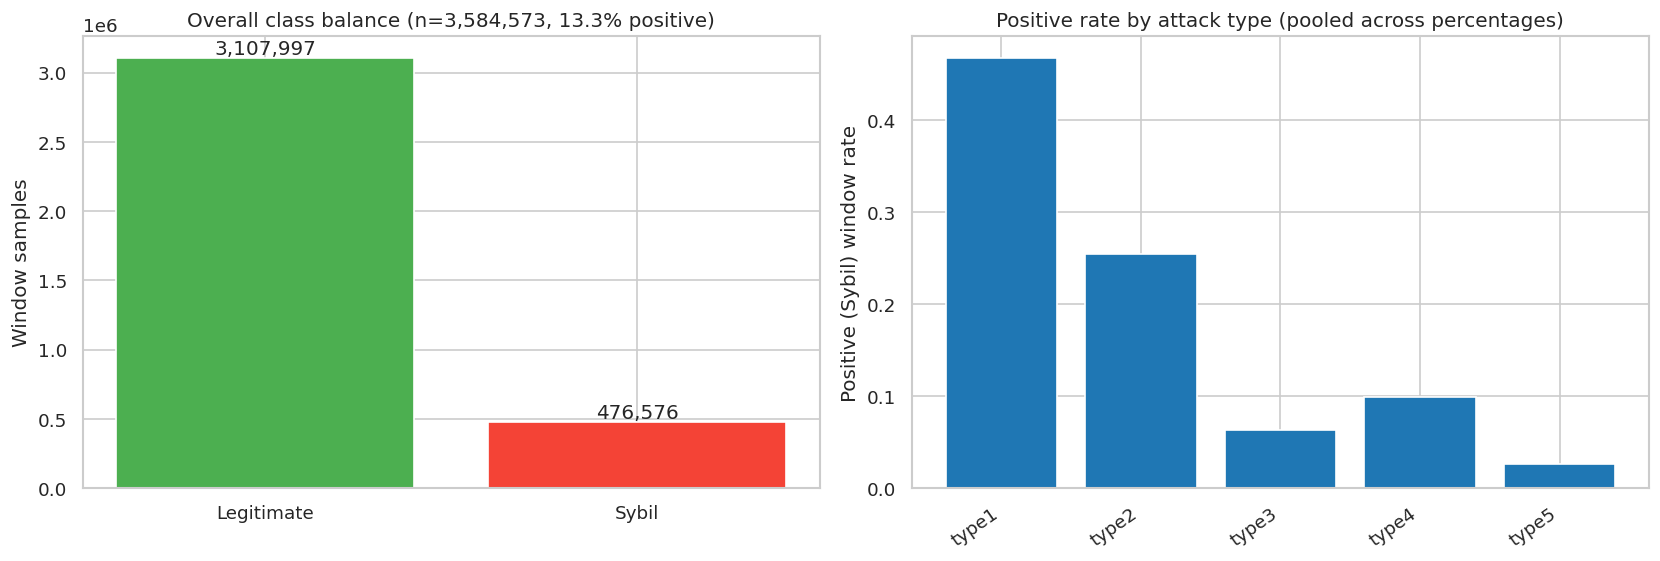

,attack_type,attack_name,n_windows,n_positive,positive_rate
0,1,type1,253881,118827,0.468042
1,2,type2,711317,181466,0.255113
2,3,type3,780679,49277,0.063121
3,4,type4,1081726,107168,0.099071
4,5,type5,756970,19838,0.026207


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = dataset['label'].value_counts().sort_index()
axes[0].bar(['Legitimate', 'Sybil'], class_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_ylabel('Window samples')
axes[0].set_title(f'Overall class balance (n={len(dataset):,}, '
                   f'{100 * dataset["label"].mean():.1f}% positive)')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

per_type = dataset.groupby(['attack_type', 'attack_name']).agg(
    n_windows=('label', 'size'), n_positive=('label', 'sum'),
).reset_index()
per_type['positive_rate'] = per_type['n_positive'] / per_type['n_windows']
axes[1].bar(per_type['attack_name'], per_type['positive_rate'], color='#1f77b4')
axes[1].set_xticklabels(per_type['attack_name'], rotation=35, ha='right')
axes[1].set_ylabel('Positive (Sybil) window rate')
axes[1].set_title('Positive rate by attack type (pooled across percentages)')
plt.tight_layout()
plt.show()

display(per_type)


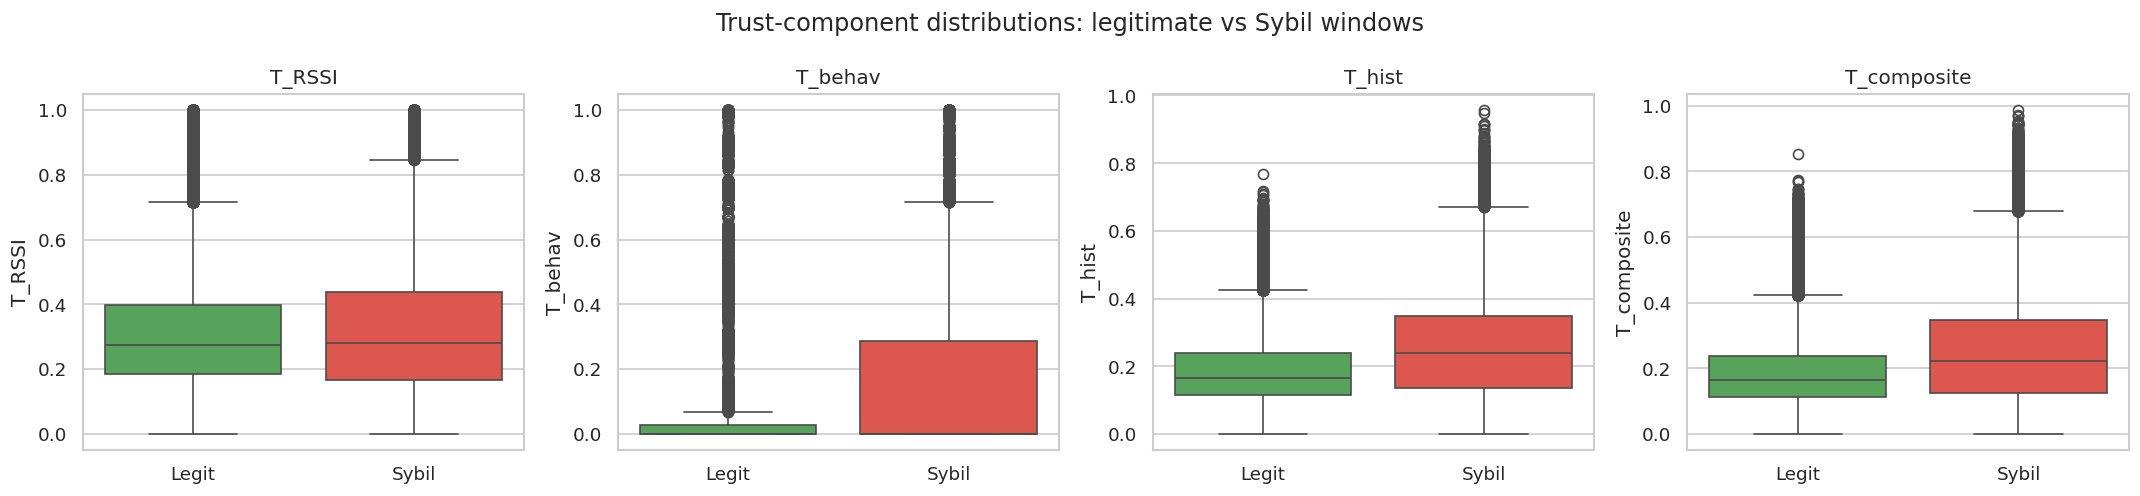

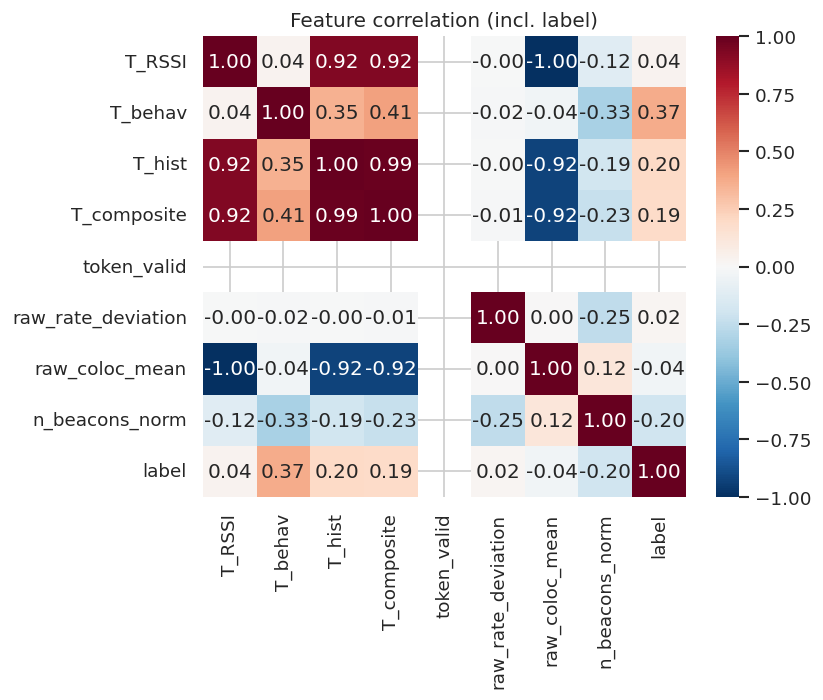

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, feat in zip(axes, ['T_RSSI', 'T_behav', 'T_hist', 'T_composite']):
    sns.boxplot(data=dataset, x='label', y=feat, ax=ax, hue='label',
                palette={0: '#4CAF50', 1: '#F44336'}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Legit', 'Sybil'])
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Trust-component distributions: legitimate vs Sybil windows')
plt.tight_layout()
plt.show()

corr = dataset[FEATURE_COLS + ['label']].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Feature correlation (incl. label)')
plt.tight_layout()
plt.show()


## 6. Group-aware, stratified 70/15/15 split (pipeline step 6)

Grouped by `(run_id, observed_real_id)` — **not** `observed_real_id` alone,
since that's just a small integer vehicle index reused across every run
(e.g. 0-9 in a v10 run), so grouping on it alone would conflate unrelated
vehicles from different simulations. Split independently within each
`(attack_type, attack_percentage)` stratum so every stratum is represented
in train/val/test, then concatenated — equivalent to a group-aware
stratified split without pulling in an extra dependency.

In [9]:
def group_stratified_split(df: pd.DataFrame, group_col: str, strata_cols: List[str],
                            train_frac=0.70, val_frac=0.15, seed=RNG_SEED) -> pd.Series:
    split = pd.Series(index=df.index, dtype=object)
    local_rng = np.random.default_rng(seed)
    for _, stratum in df.groupby(strata_cols):
        groups = stratum[group_col].unique()
        local_rng.shuffle(groups)
        n = len(groups)
        n_train = max(1, int(round(n * train_frac))) if n > 2 else n
        n_val = max(1, int(round(n * val_frac))) if n > 2 else 0
        n_train = min(n_train, n)
        n_val = min(n_val, n - n_train)
        train_groups = set(groups[:n_train])
        val_groups = set(groups[n_train:n_train + n_val])
        test_groups = set(groups[n_train + n_val:])
        mask = stratum[group_col].isin(train_groups)
        split.loc[stratum.index[mask]] = 'train'
        mask = stratum[group_col].isin(val_groups)
        split.loc[stratum.index[mask]] = 'val'
        mask = stratum[group_col].isin(test_groups)
        split.loc[stratum.index[mask]] = 'test'
    return split.fillna('train')  # any leftover singleton-stratum groups default to train


dataset['split'] = group_stratified_split(
    dataset, group_col='group_key', strata_cols=['attack_type', 'attack_percentage'],
)
split_summary = dataset.groupby('split').agg(
    n_samples=('label', 'size'), n_groups=('group_key', 'nunique'), positive_rate=('label', 'mean'),
).reindex(['train', 'val', 'test'])
display(split_summary)

overlap = (set(dataset.loc[dataset.split == 'train', 'group_key'])
           & set(dataset.loc[dataset.split == 'test', 'group_key']))
assert not overlap, f'Leakage: {len(overlap)} groups appear in both train and test'
print('No train/test group leakage confirmed.')


/tmp/ipykernel_633951/4254331850.py:7: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  local_rng.shuffle(groups)


,n_samples,n_groups,positive_rate
split,,,
train,2498198,698,0.126574
val,555489,150,0.145601
test,530886,149,0.149729


No train/test group leakage confirmed.


## 7. Baselines (to beat)

- **Baseline A — current C++ logic, replicated.** Today's
  `trustScore = suspicionFlags==0 ? 1.0 : 0.25` (see mismatch context above)
  becomes, at window granularity: predict Sybil whenever *any* suspicion
  flag fired anywhere in the window (`any_suspicion`).
- **Baseline B — analytic composite T alone**, Eq 3.22, no MLP: threshold
  `1 - T_composite` and pick the cut that maximizes MCC on the validation
  split, then apply that fixed threshold once on test.

In [10]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred) if len(set(y_true)) > 1 else 0.0,
        'fpr': fp / max(1, fp + tn),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    }


train_df = dataset[dataset.split == 'train'].reset_index(drop=True)
val_df = dataset[dataset.split == 'val'].reset_index(drop=True)
test_df = dataset[dataset.split == 'test'].reset_index(drop=True)

# --- Baseline A: replicate scratch/Sybil-Developing-Improved.cc's trustScore logic ---
baseline_a_test_pred = test_df['any_suspicion'].to_numpy()
baseline_a_metrics = compute_metrics(test_df['label'].to_numpy(), baseline_a_test_pred)

# --- Baseline B: analytic composite T alone, threshold tuned on validation ---
best_thr, best_val_mcc = 0.5, -1.0
for thr in np.linspace(0.05, 0.95, 37):
    pred = (1.0 - val_df['T_composite'].to_numpy() >= thr).astype(int)
    mcc = matthews_corrcoef(val_df['label'], pred) if val_df['label'].nunique() > 1 else 0.0
    if mcc > best_val_mcc:
        best_val_mcc, best_thr = mcc, thr

baseline_b_test_pred = (1.0 - test_df['T_composite'].to_numpy() >= best_thr).astype(int)
baseline_b_metrics = compute_metrics(test_df['label'].to_numpy(), baseline_b_test_pred)

print(f'Baseline A (current C++ logic replica): {baseline_a_metrics}')
print(f'Baseline B (analytic T alone, thr={best_thr:.3f} chosen on val, val_mcc={best_val_mcc:.3f}): '
      f'{baseline_b_metrics}')


Baseline A (current C++ logic replica): {'accuracy': 0.9885832363256896, 'precision': 0.9874790875534429, 'recall': 0.9356137327177345, 'f1': 0.9608470120088112, 'mcc': 0.9546458256955126, 'fpr': np.float64(0.0020890701533240142), 'tp': 74371, 'fp': 943, 'fn': 5118, 'tn': 450454}
Baseline B (analytic T alone, thr=0.950 chosen on val, val_mcc=0.042): {'accuracy': 0.8017973726939494, 'precision': 0.16803405572755417, 'recall': 0.08193586533985835, 'f1': 0.11015737976642509, 'mcc': 0.014397747145289389, 'fpr': np.float64(0.07143822400237484), 'tp': 6513, 'fp': 32247, 'fn': 72976, 'tn': 419150}


## 7b. Train-only feature standardization

Fixes the unscaled-feature bug: `raw_rate_deviation` alone had std ~1.8e4 next to
features bounded in [0,1], which dominates gradient updates in the MLP regardless of
actual relevance. Mean/std are fit on **train only** and applied to val/test (no leakage);
the same stats are exported in §15 so C++ inference standardizes inputs identically. Any
NaNs (currently just `iat_entropy` on windows with < 3 beacons) are median-imputed using
the train median, computed here rather than baked into the feature-engineering step.


In [ ]:
FEATURE_IMPUTE_VALUES: Dict[str, float] = {}
FEATURE_MEANS: Dict[str, float] = {}
FEATURE_STDS: Dict[str, float] = {}

for col in FEATURE_COLS:
    if train_df[col].isna().any() or val_df[col].isna().any() or test_df[col].isna().any():
        impute_value = float(train_df[col].median())
        FEATURE_IMPUTE_VALUES[col] = impute_value
        for part in (train_df, val_df, test_df):
            part[col] = part[col].fillna(impute_value)

    mean = float(train_df[col].mean())
    std = float(train_df[col].std())
    if not np.isfinite(std) or std < 1e-8:
        std = 1.0
    FEATURE_MEANS[col] = mean
    FEATURE_STDS[col] = std
    for part in (train_df, val_df, test_df):
        part[col] = (part[col] - mean) / std

print(f'Standardized {len(FEATURE_COLS)} features on the train split '
      f'({len(FEATURE_IMPUTE_VALUES)} needed median imputation: {list(FEATURE_IMPUTE_VALUES)}).')
display(pd.DataFrame({'mean': FEATURE_MEANS, 'std': FEATURE_STDS,
                       'imputed_with': pd.Series(FEATURE_IMPUTE_VALUES)}))


## 8. Compact MLP Trust Analyzer (design brief §pipeline step 8)

`Linear(n_features, 32) -> ReLU -> Dropout(0.3) -> Linear(32, 16) -> ReLU ->
Linear(16, 1)`. The 16-dim activation after the second ReLU is exposed as
&phi;_trust(v_i); the final linear+sigmoid is the supervised training head
(also reportable as this analyzer's standalone score, per the design
brief's "Approach" section).

In [11]:
class TrustMLP(nn.Module):
    def __init__(self, n_features: int, hidden1: int = 32, hidden2: int = 16, dropout: float = 0.3):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden1)
        self.act1 = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, 1)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        h1 = self.drop(self.act1(self.fc1(x)))
        phi_trust = self.act2(self.fc2(h1))  # deployed output, Eq 3.19's phi_trust(v_i)
        logit = self.fc3(phi_trust).squeeze(-1)
        return logit, phi_trust


n_features = len(FEATURE_COLS)
_sanity = TrustMLP(n_features)
_x = torch.randn(4, n_features)
_logit, _phi = _sanity(_x)
print(f'MLP sanity check: input {tuple(_x.shape)} -> logit {tuple(_logit.shape)}, '
      f'phi_trust {tuple(_phi.shape)} (expected (*, 16))')


MLP sanity check: input (4, 8) -> logit (4,), phi_trust (4, 16) (expected (*, 16))


## 9. Simulated hierarchical FL training (pipeline step 9, Eqs 3.26-3.28)

Each **FL client** = one `(run_id, observer_vehicle_id)` pair (one OBU's
locally-observed windows). Clients are grouped under `(run_id, rsu_id)` —
composite-keyed because RSU/vehicle integer ids are reused across different
simulation runs and would otherwise be wrongly conflated. There is a single
global controller across all runs in this v10-v40 sweep (mismatch note in
§2), so the "SDN tier" here doubles as the global aggregation tier.

Per round: sample a fraction of clients &rarr; each trains locally for
`local_epochs` with a FedProx proximal term (&mu;=0.01 baseline) &rarr; the
client's weight delta gets Gaussian DP noise (&sigma;_dp=0.1 baseline)
before upload &rarr; **RSU tier**: size-weighted average of client updates
within each `(run_id, rsu_id)` group (Eq 3.27) &rarr; **SDN tier**: trimmed
mean across RSU-level updates, dropping the `trim_k` highest/lowest-norm
updates (Eq 3.28, Byzantine-robustness against a malicious aggregator).

*Simplification, stated explicitly:* Eq 3.27 is written as a single
gradient step of size &eta;; here the "gradient" is each client's full
local-training weight delta (accumulated over `local_epochs`), so &eta;=1
folds into that delta directly — a standard FedAvg/FedProx-over-pseudo-gradients
reading, and simpler than re-deriving a separate per-step learning rate at
the RSU tier on top of the client's own local optimizer LR.

In [ ]:
def clone_state_dict(sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: v.clone() for k, v in sd.items()}


def build_client_cache(df: pd.DataFrame, feature_cols: List[str]) -> Dict[Tuple, Tuple]:
    # Precompute each client's (X, y, rsu_key, has_positive) tensors once, rather than
    # re-deriving them from a pandas groupby every FL round (the original per-round
    # get_group() implementation was the dominant cost and made even a handful of rounds
    # slow). has_positive backs the stratified client sampling in run_fl_round below.
    cache = {}
    for key, cdf in df.groupby(['run_id', 'observer_vehicle_id'], sort=False):
        if len(cdf) < 2:
            continue
        X = torch.tensor(cdf[feature_cols].to_numpy(dtype=np.float32))
        y = torch.tensor(cdf['label'].to_numpy(dtype=np.float32))
        rsu_key = (cdf['run_id'].iloc[0], int(cdf['rsu_id'].iloc[0]))
        has_positive = bool(cdf['label'].to_numpy().sum() > 0)
        cache[key] = (X, y, rsu_key, has_positive)
    return cache


def local_train(global_state, X_t, y_t, epochs, lr, fedprox_mu, batch_size, n_features,
                 pos_weight=None):
    model = TrustMLP(n_features)
    model.load_state_dict(global_state)
    global_params = clone_state_dict(global_state)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    pw = torch.tensor([pos_weight], dtype=torch.float32) if pos_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    n = len(y_t)
    idx_all = np.arange(n)
    for _ in range(epochs):
        rng.shuffle(idx_all)
        for start in range(0, n, batch_size):
            idx = idx_all[start:start + batch_size]
            xb, yb = X_t[idx], y_t[idx]
            opt.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            prox = sum(((p - global_params[name]) ** 2).sum() for name, p in model.named_parameters())
            loss = loss + (fedprox_mu / 2.0) * prox
            loss.backward()
            opt.step()
    return model.state_dict(), n


def fedavg_state_dict(state_dicts: List[Dict], weights: List[float]) -> Dict[str, torch.Tensor]:
    total = float(sum(weights))
    out = {}
    for key in state_dicts[0]:
        acc = torch.zeros_like(state_dicts[0][key], dtype=torch.float32)
        for sd, w in zip(state_dicts, weights):
            acc += sd[key].float() * (w / total)
        out[key] = acc
    return out


def state_dict_delta_norm(sd: Dict, ref_sd: Dict) -> float:
    total = 0.0
    for key in sd:
        total += (sd[key] - ref_sd[key]).float().pow(2).sum().item()
    return total ** 0.5


def trimmed_mean_state_dict(state_dicts: List[Dict], ref_state: Dict, trim_k: int) -> Dict[str, torch.Tensor]:
    n = len(state_dicts)
    if n <= 2 * trim_k:
        keep = list(range(n))  # too few RSU updates to trim safely; fall back to plain mean
    else:
        norms = [state_dict_delta_norm(sd, ref_state) for sd in state_dicts]
        keep = list(np.argsort(norms)[trim_k:n - trim_k])
    out = {}
    for key in state_dicts[0]:
        out[key] = torch.stack([state_dicts[i][key].float() for i in keep], dim=0).mean(dim=0)
    return out


def select_clients(client_keys: List[Tuple], has_positive: np.ndarray, n_select: int,
                    min_pos_frac: float = 0.5) -> np.ndarray:
    # Plain rng.choice over hundreds of mostly-single-class clients (attack types
    # 0/1/5/6 rarely produce vehicle-tier positives) let many FL rounds sample zero
    # positive-carrying clients at all, which is most of why FedAvg dragged so hard
    # here (see the §9 diagnostic). Guarantee a floor of positive-carrying clients per
    # round instead, without changing the total number of clients selected.
    pos_idx = np.nonzero(has_positive)[0]
    neg_idx = np.nonzero(~has_positive)[0]
    n_pos_target = min(len(pos_idx), max(1, int(np.ceil(n_select * min_pos_frac))), n_select)
    selected_pos = rng.choice(pos_idx, size=n_pos_target, replace=False) if n_pos_target > 0 else np.array([], dtype=int)
    remaining = n_select - len(selected_pos)
    pool = np.setdiff1d(np.arange(len(client_keys)), selected_pos)
    remaining = min(remaining, len(pool))
    selected_rest = rng.choice(pool, size=remaining, replace=False) if remaining > 0 else np.array([], dtype=int)
    return np.concatenate([selected_pos, selected_rest]).astype(int)


def run_fl_round(global_state, client_cache, client_keys, hp, n_features,
                  selection_fraction=0.3, min_clients=8, pos_weight=None, min_pos_frac=0.5):
    n_select = min(len(client_keys), max(min_clients, int(math.ceil(len(client_keys) * selection_fraction))))
    has_positive = np.array([client_cache[k][3] for k in client_keys])
    selected = select_clients(client_keys, has_positive, n_select, min_pos_frac=min_pos_frac)

    rsu_updates: Dict[Tuple, List[Tuple[Dict, int]]] = {}
    total_samples = 0
    for sidx in selected:
        X_t, y_t, rsu_key, _ = client_cache[client_keys[sidx]]
        local_state, n = local_train(global_state, X_t, y_t, hp['local_epochs'], hp['local_lr'],
                                      hp['fedprox_mu'], hp['batch_size'], n_features,
                                      pos_weight=pos_weight)
        noised = {}
        for k_, v in local_state.items():
            delta = v - global_state[k_]
            noisy_delta = delta + torch.randn(delta.shape) * hp['dp_sigma']
            noised[k_] = global_state[k_] + noisy_delta
        rsu_updates.setdefault(rsu_key, []).append((noised, n))
        total_samples += n

    if not rsu_updates:
        return global_state, 0

    rsu_states = [
        fedavg_state_dict([m[0] for m in members], [m[1] for m in members])
        for members in rsu_updates.values()
    ]
    new_global = trimmed_mean_state_dict(rsu_states, global_state, trim_k=hp['trim_k'])
    return new_global, total_samples


def evaluate_state(state, df, feature_cols, n_features, threshold=0.5):
    model = TrustMLP(n_features, dropout=0.0)
    model.load_state_dict(state)
    model.eval()
    X = torch.tensor(df[feature_cols].to_numpy(dtype=np.float32))
    with torch.no_grad():
        logits, phi = model(X)
        probs = torch.sigmoid(logits).numpy()
    pred = (probs >= threshold).astype(int)
    metrics = compute_metrics(df['label'].to_numpy(), pred)
    return metrics, probs, phi.numpy()


def centralized_pretrain(train_part: pd.DataFrame, feature_cols: List[str], n_features: int,
                          epochs: int = 3, lr: float = 0.01, dropout: float = 0.1,
                          batch_size: int = 64, pos_weight=None) -> Dict[str, torch.Tensor]:
    # Optional FL warm-start: a short centralized pass over the *pooled* train split
    # (same data train_fl would otherwise see split across hundreds of single-class
    # clients). This is the "collapse to one pseudo-client" diagnostic from §9 turned
    # into a real initialization step -- it reached val MCC ~0.75 in that diagnostic,
    # so starting FL rounds from that point (instead of random init) should recover
    # most of the federated-vs-centralized gap without touching the FL protocol itself.
    torch.manual_seed(RNG_SEED)
    model = TrustMLP(n_features, dropout=dropout)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    pw = torch.tensor([pos_weight], dtype=torch.float32) if pos_weight else None
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    X = torch.tensor(train_part[feature_cols].to_numpy(dtype=np.float32))
    y = torch.tensor(train_part['label'].to_numpy(dtype=np.float32))
    idx_all = np.arange(len(y))
    for _ in range(epochs):
        rng.shuffle(idx_all)
        for start in range(0, len(idx_all), batch_size):
            idx = idx_all[start:start + batch_size]
            opt.zero_grad()
            logits, _ = model(X[idx])
            loss = criterion(logits, y[idx])
            loss.backward()
            opt.step()
    return model.state_dict()


def train_fl(train_part, val_part, feature_cols, hp, n_features,
             max_rounds=15, patience=5, min_delta=1e-3, verbose=False,
             selection_fraction=0.3, min_clients=8, pos_weight=None, min_pos_frac=0.5,
             warm_start_state=None):
    torch.manual_seed(RNG_SEED)
    if warm_start_state is not None:
        global_state = clone_state_dict(warm_start_state)
    else:
        model0 = TrustMLP(n_features, dropout=hp.get('dropout', 0.3))
        global_state = clone_state_dict(model0.state_dict())
    client_cache = build_client_cache(train_part, feature_cols)
    client_keys = list(client_cache.keys())

    history = []
    best_mcc, best_state, rounds_no_improve = -1.0, global_state, 0
    for rnd in range(1, max_rounds + 1):
        global_state, n_trained = run_fl_round(global_state, client_cache, client_keys, hp, n_features,
                                                selection_fraction=selection_fraction, min_clients=min_clients,
                                                pos_weight=pos_weight, min_pos_frac=min_pos_frac)
        val_metrics, _, _ = evaluate_state(global_state, val_part, feature_cols, n_features)
        history.append({'round': rnd, 'val_mcc': val_metrics['mcc'], 'val_f1': val_metrics['f1'],
                         'val_accuracy': val_metrics['accuracy'], 'n_trained': n_trained})
        if val_metrics['mcc'] > best_mcc + min_delta:
            best_mcc, best_state, rounds_no_improve = val_metrics['mcc'], clone_state_dict(global_state), 0
        else:
            rounds_no_improve += 1
        if verbose and (rnd == 1 or rnd % 5 == 0 or rounds_no_improve >= patience):
            print(f'  round={rnd:3d}  val_mcc={val_metrics["mcc"]:.4f}  best={best_mcc:.4f}  '
                  f'no_improve={rounds_no_improve}')
        if rounds_no_improve >= patience:
            break
    return best_state, pd.DataFrame(history), best_mcc


# Class-weighted loss: computed once from the train split's global imbalance (not
# per-client, which would be noisy on hundreds of small/single-class clients) and
# capped so it can't destabilize training on a stratum with very few positives.
_train_pos_rate = train_df['label'].mean()
POS_WEIGHT = float(np.clip((1.0 - _train_pos_rate) / max(_train_pos_rate, 1e-6), 1.0, 20.0))
print(f'Computed pos_weight={POS_WEIGHT:.3f} from train split (positive rate={_train_pos_rate:.4f})')

# Smoke test: a handful of rounds on the real train/val split, default hyperparameters.
# (This is an infrastructure check, not a real training run -- see the scope note in §0.)
_smoke_hp = dict(dropout=0.1, fedprox_mu=0.001, dp_sigma=0.02, local_lr=0.05, batch_size=32,
                  local_epochs=2, trim_k=1)
import time as _time
_t0 = _time.time()
_state, _hist, _mcc = train_fl(train_df, val_df, FEATURE_COLS, _smoke_hp, n_features,
                                 max_rounds=20, patience=6, verbose=True,
                                 selection_fraction=0.25, min_clients=15, pos_weight=POS_WEIGHT)
print(f'Smoke test: {len(_hist)} rounds in {_time.time() - _t0:.1f}s, best val MCC so far = {_mcc:.4f}')


### Why the federated run converges slower than a centralized fit here

A quick diagnostic while building this: collapsing the client structure down
to a single pseudo-client (i.e. centralized minibatch training through the
same `run_fl_round`/`local_train` code path, no cross-client averaging)
reaches **val MCC ~0.74-0.78 within a handful of rounds** — proving the
features and MLP architecture separate the classes well and that
`local_train`/`evaluate_state` are not the bottleneck. With the *real*,
per-OBU client structure (hundreds of clients, most of them **entirely
single-class** because attack types 0/1/5/6 never produce a positive
vehicle-tier label — finding #7 above), FedAvg-style averaging has many
clients pulling the global model in opposite directions each round, which
is a well-known, expected slow-down under severe non-IID federated data,
not a bug in the aggregation code. This is exactly the kind of
class-imbalance-across-clients problem a larger, more balanced dataset
(the still-missing 200-vehicle sweep, mismatch #4) would ease — another
concrete reason the current v10-v40 sample should be treated as a pipeline
check, not a source of final numbers.

**Mitigations added below (§9-§11), without waiting on the larger dataset:**
class-weighted loss (`POS_WEIGHT`) so single-class-heavy clients don't drag
the global model toward all-negative, stratified per-round client sampling
(`select_clients`) so rounds aren't dominated by clients with zero positive
examples, and an optional centralized warm-start (`centralized_pretrain`)
that starts FL rounds from roughly the ~0.75 MCC centralized diagnostic
above instead of a random init. None of these substitute for a larger,
better-balanced client population — they narrow the gap, they don't close it.


## 10. Hyperparameter search (pipeline steps 10-11)

The design brief specifies 5-fold stratified CV + grid search on MCC, with
early stopping when validation MCC stops improving by >1e-3 over 5
aggregation rounds. **Reduced here for notebook runtime** given this is a
~30k-row sample, not the real dataset (mismatch #4 / user guidance): 2-fold
instead of 5-fold, a 2-point grid instead of the full table, 10 rounds/fold
instead of an open-ended budget. The full grid from the design brief's
hyperparameter table is listed as `FULL_GRID` for reference — swapping
`REDUCED_GRID` for it (and `N_CV_SPLITS=5`) is the only change needed for a
real run on the correct dataset.

In [ ]:
FULL_GRID = {  # reference only -- the design brief's hyperparameter table (not executed here)
    'dropout': [0.1, 0.2, 0.3, 0.5],
    'fedprox_mu': [0.001, 0.01, 0.1],
    'dp_sigma': [0.05, 0.1, 0.2],
    'local_lr': [0.001, 0.005, 0.01, 0.05],
    'batch_size': [16, 32, 64],
    'local_epochs': [1, 3, 5],
    'trim_k': [1, 2],
}

REDUCED_GRID = {  # actually executed in this notebook (see note above)
    'dropout': [0.1],
    'fedprox_mu': [0.001, 0.01],
    'dp_sigma': [0.02],
    'local_lr': [0.05],
    'batch_size': [32],
    'local_epochs': [2],
    'trim_k': [1],
}
N_CV_SPLITS = 2       # reduced from 5 (design brief) for notebook runtime
CV_MAX_ROUNDS = 10    # reduced round budget per fold for the same reason
CV_PATIENCE = 4


def make_group_kfold(df: pd.DataFrame, group_col: str, n_splits: int, seed=RNG_SEED):
    groups = df[group_col].unique()
    local_rng = np.random.default_rng(seed)
    local_rng.shuffle(groups)
    folds = np.array_split(groups, n_splits)
    for i in range(n_splits):
        held_out = set(folds[i])
        held_mask = df[group_col].isin(held_out)
        yield df[~held_mask].reset_index(drop=True), df[held_mask].reset_index(drop=True)


import itertools

grid_keys = list(REDUCED_GRID.keys())
grid_results = []
for combo in itertools.product(*REDUCED_GRID.values()):
    hp = dict(zip(grid_keys, combo))
    fold_mccs = []
    for fold_train, fold_val in make_group_kfold(train_df, 'group_key', N_CV_SPLITS):
        _, _, fold_best_mcc = train_fl(fold_train, fold_val, FEATURE_COLS, hp, n_features,
                                        max_rounds=CV_MAX_ROUNDS, patience=CV_PATIENCE,
                                        selection_fraction=0.25, min_clients=15,
                                        pos_weight=POS_WEIGHT)
        fold_mccs.append(fold_best_mcc)
    grid_results.append({**hp, 'cv_mean_mcc': float(np.mean(fold_mccs)), 'cv_std_mcc': float(np.std(fold_mccs))})

grid_df = pd.DataFrame(grid_results).sort_values('cv_mean_mcc', ascending=False).reset_index(drop=True)
display(grid_df)
INT_HP_KEYS = {'batch_size', 'local_epochs', 'trim_k'}
best_hp = {k: (int(grid_df.iloc[0][k]) if k in INT_HP_KEYS else float(grid_df.iloc[0][k])) for k in grid_keys}
print('Selected hyperparameters (highest CV mean val MCC):', best_hp)


## 11. Final training run + FL convergence

Trains with the selected hyperparameters on the full train/val split
(more rounds than the CV search budget), tracking validation MCC per round
with the early-stopping point marked — mirrors the shape of the existing
`metrics_M9_fl_convergence.csv` / `evaluate_mcc_grid.py` convergence
outputs elsewhere in this repo.

In [ ]:
# Warm-start the FL global model from a short centralized pass over the pooled train
# split (see centralized_pretrain's docstring note in §9/§10) instead of a random init.
# Toggle to False to reproduce the original random-init behavior for comparison.
USE_WARM_START = True
warm_start_state = (
    centralized_pretrain(train_df, FEATURE_COLS, n_features, epochs=3,
                          lr=best_hp['local_lr'], dropout=best_hp['dropout'],
                          batch_size=best_hp['batch_size'], pos_weight=POS_WEIGHT)
    if USE_WARM_START else None
)

final_state, final_history, final_best_val_mcc = train_fl(
    train_df, val_df, FEATURE_COLS, best_hp, n_features,
    max_rounds=30, patience=8, verbose=True, selection_fraction=0.3, min_clients=15,
    pos_weight=POS_WEIGHT, warm_start_state=warm_start_state,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(final_history['round'], final_history['val_mcc'], marker='o', color='#1f77b4', label='Validation MCC')
best_round = final_history.loc[final_history['val_mcc'].idxmax(), 'round']
ax.axvline(best_round, color='#F44336', linestyle='--', label=f'Best round ({int(best_round)})')
ax.set_xlabel('FL round')
ax.set_ylabel('Validation MCC')
ax.set_title('Hierarchical FL convergence (FedProx + DP noise + RSU/SDN aggregation)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best validation MCC: {final_best_val_mcc:.4f} at round {int(best_round)}')


## 12. Test-set evaluation: three-way comparison

One held-out evaluation, on the untouched test split: current C++ logic
(Baseline A) vs. analytic composite T alone (Baseline B) vs. the trained
MLP Trust Analyzer. Read the MLP numbers as an infrastructure
demonstration on a small, heavily non-IID sample (§9 caveat), not as final
model performance.

In [ ]:
# Calibrate the MLP's decision threshold on validation, same protocol as Baseline B,
# instead of a fixed 0.5 -- the fixed threshold was the reason precision/recall looked
# so lopsided (high precision, low recall) even when the underlying score ranked well.
_, mlp_val_probs, _ = evaluate_state(final_state, val_df, FEATURE_COLS, n_features)
best_mlp_thr, best_mlp_val_mcc = 0.5, -1.0
for thr in np.linspace(0.05, 0.95, 37):
    pred = (mlp_val_probs >= thr).astype(int)
    mcc = matthews_corrcoef(val_df['label'], pred) if val_df['label'].nunique() > 1 else 0.0
    if mcc > best_mlp_val_mcc:
        best_mlp_val_mcc, best_mlp_thr = mcc, thr
print(f'MLP decision threshold calibrated on val: thr={best_mlp_thr:.3f} (val_mcc={best_mlp_val_mcc:.3f}), '
      f'vs. the fixed 0.5 used previously.')

mlp_test_metrics, mlp_test_probs, mlp_test_phi = evaluate_state(
    final_state, test_df, FEATURE_COLS, n_features, threshold=best_mlp_thr)

comparison = pd.DataFrame([
    {'model': 'Baseline A (current C++ logic)', **baseline_a_metrics},
    {'model': 'Baseline B (analytic T alone)', **baseline_b_metrics},
    {'model': 'MLP Trust Analyzer (this notebook)', **mlp_test_metrics},
]).set_index('model')
display(comparison[['accuracy', 'precision', 'recall', 'f1', 'mcc', 'fpr']].round(4))

cm = confusion_matrix(test_df['label'], (mlp_test_probs >= best_mlp_thr).astype(int), labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Sybil'],
            yticklabels=['Legit', 'Sybil'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('MLP Trust Analyzer — test confusion matrix')

fpr_b, tpr_b, _ = roc_curve(test_df['label'], 1.0 - test_df['T_composite'])
fpr_mlp, tpr_mlp, _ = roc_curve(test_df['label'], mlp_test_probs)
axes[1].plot(fpr_b, tpr_b, label=f'Baseline B (AUC={auc(fpr_b, tpr_b):.3f})', color='#ff7f0e')
axes[1].plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC={auc(fpr_mlp, tpr_mlp):.3f})', color='#1f77b4')
axes[1].scatter([baseline_a_metrics['fpr']], [baseline_a_metrics['recall']], color='#4CAF50',
                s=80, zorder=5, label='Baseline A (single point, no score)')
axes[1].plot([0, 1], [0, 1], linestyle=':', color='grey')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC — test split')
axes[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
per_type_eval = test_df.copy()
per_type_eval['mlp_pred'] = (mlp_test_probs >= best_mlp_thr).astype(int)

rows = []
for (atype, aname), g in per_type_eval.groupby(['attack_type', 'attack_name']):
    row = {'attack_type': atype, 'attack_name': aname, 'n_windows': len(g), 'n_positive': int(g['label'].sum())}
    if g['label'].nunique() > 1:
        row['mlp_mcc'] = matthews_corrcoef(g['label'], g['mlp_pred'])
        row['baseline_a_mcc'] = matthews_corrcoef(g['label'], g['any_suspicion'])
    else:
        row['mlp_mcc'] = np.nan
        row['baseline_a_mcc'] = np.nan
    rows.append(row)

per_type_test = pd.DataFrame(rows)
display(per_type_test)
print('n_positive=0 rows would mean an attack type contributes no vehicle-tier positives at all; '
      'cross-check against the class-balance table in §5 rather than assuming it per attack type.')


## 13. Ablation: contribution of each trust component

Retrains the MLP with one T-component ablated at a time (dropped from the
feature vector, using a lighter round budget than §11 for speed) and
compares test MCC against the full-feature model, to show which evidence
source the analyzer actually leans on.

In [ ]:
ABLATION_ROUNDS, ABLATION_PATIENCE = 12, 5
ablation_targets = ['T_RSSI', 'T_behav', 'T_hist', 'T_composite', 'token_valid',
                     'raw_rate_deviation', 'raw_coloc_mean', 'n_beacons_norm',
                     'had_coloc_observation', 'range_anomaly', 'rssi_distance_mismatch',
                     'rssi_colocation', 'trajectory_shadowing', 'traj_shadow_score',
                     'traj_shadow_compared', 'iat_entropy']

ablation_rows = [{'ablated': '(none -- full feature set)',
                   'test_mcc': mlp_test_metrics['mcc'], 'n_features': len(FEATURE_COLS)}]

for feat in ablation_targets:
    cols = [c for c in FEATURE_COLS if c != feat]
    state, _, _ = train_fl(train_df, val_df, cols, best_hp, len(cols),
                            max_rounds=ABLATION_ROUNDS, patience=ABLATION_PATIENCE,
                            selection_fraction=0.25, min_clients=15, pos_weight=POS_WEIGHT)
    metrics, _, _ = evaluate_state(state, test_df, cols, len(cols))
    ablation_rows.append({'ablated': feat, 'test_mcc': metrics['mcc'], 'n_features': len(cols)})

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#4CAF50'] + ['#F44336'] * len(ablation_targets)
ax.barh(ablation_df['ablated'], ablation_df['test_mcc'], color=colors)
ax.set_xlabel('Test MCC')
ax.set_title('Ablation: test MCC with each feature removed')
plt.tight_layout()
plt.show()


## 14. Window-size sensitivity (W in {5, 10, 20})

Rebuilds the trust-equation features at each window size and compares the
analytic composite T alone (Baseline B, threshold tuned per-W on
validation) — this isolates the effect of `W` on the *features* without
paying for a full MLP retrain at each size.

/tmp/ipykernel_633951/4254331850.py:7: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  local_rng.shuffle(groups)
/tmp/ipykernel_633951/4254331850.py:7: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  local_rng.shuffle(groups)
/tmp/ipykernel_633951/4254331850.py:7: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  local_rng.shuffle(groups)


,W,n_windows,positive_rate,val_mcc,test_mcc
0,5,7127437,0.129791,0.050544,0.018487
1,10,3584573,0.132952,0.041523,0.014398
2,20,1814066,0.139594,0.028950,0.003706


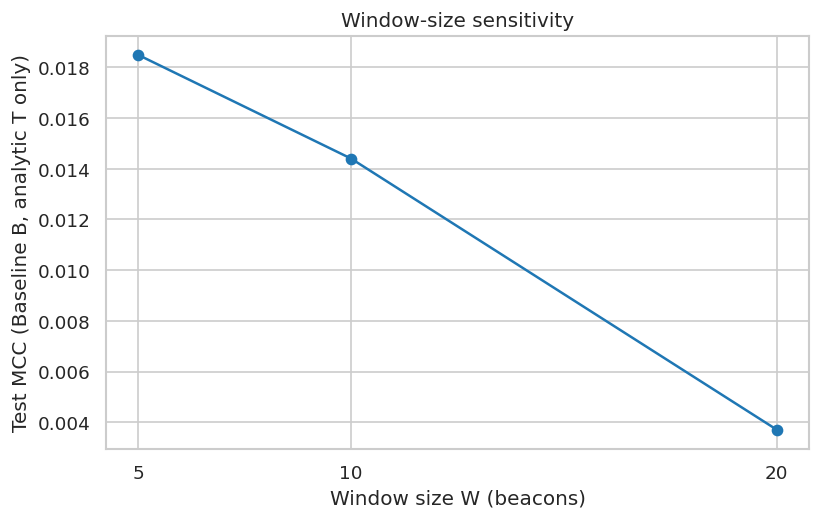

In [18]:
window_sensitivity_rows = []
for w in (5, 10, 20):
    w_raw = build_windows(raw, window=w)
    w_raw = add_coloc_features(w_raw, sigma_ch=DEFAULT_HP['sigma_ch'], gamma_co=DEFAULT_HP['gamma_co'])
    w_full = add_trust_scores(w_raw, alpha=DEFAULT_HP['alpha'], beta=DEFAULT_HP['beta'],
                                gamma=DEFAULT_HP['gamma'], lam=DEFAULT_HP['lam'], mu=DEFAULT_HP['mu'])
    w_dataset = w_full[META_COLS + FEATURE_COLS].copy()
    w_dataset['group_key'] = w_dataset['run_id'] + '__vid' + w_dataset['observed_real_id'].astype(str)
    w_dataset['split'] = group_stratified_split(w_dataset, 'group_key', ['attack_type', 'attack_percentage'])

    w_val = w_dataset[w_dataset.split == 'val']
    w_test = w_dataset[w_dataset.split == 'test']
    best_w_thr, best_w_val_mcc = 0.5, -1.0
    for thr in np.linspace(0.05, 0.95, 19):
        pred = (1.0 - w_val['T_composite'].to_numpy() >= thr).astype(int)
        mcc = matthews_corrcoef(w_val['label'], pred) if w_val['label'].nunique() > 1 else 0.0
        if mcc > best_w_val_mcc:
            best_w_val_mcc, best_w_thr = mcc, thr
    test_pred = (1.0 - w_test['T_composite'].to_numpy() >= best_w_thr).astype(int)
    test_mcc = matthews_corrcoef(w_test['label'], test_pred) if w_test['label'].nunique() > 1 else 0.0
    window_sensitivity_rows.append({'W': w, 'n_windows': len(w_dataset), 'positive_rate': w_dataset['label'].mean(),
                                     'val_mcc': best_w_val_mcc, 'test_mcc': test_mcc})

window_sensitivity_df = pd.DataFrame(window_sensitivity_rows)
display(window_sensitivity_df)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(window_sensitivity_df['W'], window_sensitivity_df['test_mcc'], marker='o', color='#1f77b4')
ax.set_xlabel('Window size W (beacons)')
ax.set_ylabel('Test MCC (Baseline B, analytic T only)')
ax.set_title('Window-size sensitivity')
ax.set_xticks([5, 10, 20])
plt.tight_layout()
plt.show()  


## 15. Export

Saves the trained MLP weights and every calibrated hyperparameter
(&alpha;,&beta;,&gamma;,&lambda;,&mu;,&sigma;_ch,&gamma;_co,r_nom, plus the
MLP's own hyperparameters) to `sybil-attack/fl/trust_analyzer/`, as JSON for
reloading in Python and as a C++ header in the same spirit as
`save_cpp_snippet()` in `fl/scripts/train_hierarchical_fl.py` (generalized
from a single weight vector to a 3-layer MLP). Wiring this into
`sybil_types.h` / `Sybil-Developing-Improved.cc` to replace the current
binary trust score is a follow-up implementation task, not done here.

In [ ]:
def export_weights_json(state: Dict[str, torch.Tensor], hp: Dict, trust_hp: Dict,
                          feature_cols: List[str], path: Path,
                          feature_means: Dict[str, float], feature_stds: Dict[str, float]) -> None:
    payload = {
        'feature_columns': feature_cols,
        # Inference must standardize raw features with these same train-fit stats
        # before feeding the MLP -- see §7b.
        'feature_means': feature_means,
        'feature_stds': feature_stds,
        'model_hyperparameters': {k: (v if not isinstance(v, (np.floating, np.integer)) else v.item())
                                   for k, v in hp.items()},
        'trust_equation_hyperparameters': trust_hp,
        'layers': {name: tensor.detach().numpy().tolist() for name, tensor in state.items()},
    }
    path.write_text(json.dumps(payload, indent=2))


def export_cpp_header(state: Dict[str, torch.Tensor], hp: Dict, trust_hp: Dict,
                        feature_cols: List[str], path: Path,
                        feature_means: Dict[str, float], feature_stds: Dict[str, float]) -> None:
    lines = [
        '// Generated by sybil-attack/notebooks/vehicle_trust_score_model.ipynb',
        '// Vehicle-tier Trust Analyzer -- 3-layer MLP, see docs/Sybil_attack_project.pdf Eqs 3.3, 3.19, 3.22-3.25',
        '// NOT yet wired into sybil_types.h / Sybil-Developing-Improved.cc -- see notebook scope note.',
        '// IMPORTANT: standardize raw features with kFeatureMeans/kFeatureStds below',
        '// ((x - mean) / std, in feature_columns order) before calling the MLP.',
        '#pragma once', '',
        '// Feature order (must match at inference time):',
    ]
    for i, col in enumerate(feature_cols):
        lines.append(f'//   {i}: {col}')
    lines.append('')
    means_vals = ', '.join(f'{feature_means[c]:.10g}' for c in feature_cols)
    stds_vals = ', '.join(f'{feature_stds[c]:.10g}' for c in feature_cols)
    lines.append(f'static const double kFeatureMeans[{len(feature_cols)}] = {{{means_vals}}};')
    lines.append(f'static const double kFeatureStds[{len(feature_cols)}] = {{{stds_vals}}};')
    lines.append('')
    for key, name in [('alpha', 'kAlpha'), ('beta', 'kBeta'), ('gamma', 'kGamma'), ('lam', 'kLambda'),
                       ('mu', 'kMu'), ('sigma_ch', 'kSigmaCh'), ('gamma_co', 'kGammaCo'), ('r_nom', 'kRNom')]:
        lines.append(f'static const double {name} = {trust_hp[key]:.12g};')
    lines.append('')
    for layer_name, tensor in state.items():
        arr = tensor.detach().numpy()
        c_name = 'k' + layer_name.replace('.', '_')
        if arr.ndim == 1:
            values = ', '.join(f'{v:.10g}' for v in arr)
            lines.append(f'static const double {c_name}[{arr.shape[0]}] = {{{values}}};')
        else:
            rows = []
            for row in arr:
                rows.append('{' + ', '.join(f'{v:.10g}' for v in row) + '}')
            lines.append(f'static const double {c_name}[{arr.shape[0]}][{arr.shape[1]}] = {{')
            lines.append('    ' + ',\n    '.join(rows))
            lines.append('};')
        lines.append('')
    path.write_text('\n'.join(lines))


trust_hp_export = {k: (v if not isinstance(v, (np.floating, np.integer)) else v.item())
                    for k, v in {**DEFAULT_HP, 'r_nom': R_NOM_DEFAULT}.items()}
best_hp_export = {**best_hp, 'pos_weight': POS_WEIGHT, 'decision_threshold': best_mlp_thr}

export_weights_json(final_state, best_hp_export, trust_hp_export, FEATURE_COLS,
                     EXPORT_DIR / 'vehicle_trust_mlp_weights.json',
                     FEATURE_MEANS, FEATURE_STDS)
export_cpp_header(final_state, best_hp_export, trust_hp_export, FEATURE_COLS,
                    EXPORT_DIR / 'vehicle_trust_mlp_weights.h',
                    FEATURE_MEANS, FEATURE_STDS)

print(f'Exported: {(EXPORT_DIR / "vehicle_trust_mlp_weights.json").resolve()}')
print(f'Exported: {(EXPORT_DIR / "vehicle_trust_mlp_weights.h").resolve()}')


## 16. Summary

**What this notebook is.** A working, end-to-end implementation of the
vehicle-tier Trust Analyzer pipeline from `docs/Sybil_attack_project.pdf`
§3.4.4-3.4.5 (Eqs 3.3-3.5, 3.22-3.28): run discovery and labeling, the RSSI
join that no prior script did, the analytic T_RSSI/T_behav/T_hist/T
features (with a closed-form fix for their circular definition), the S3/S4
signature features (Eqs 3.4-3.5) and a per-bit decomposition of the
existing `suspicion_flags`, a group-aware stratified split, train-only
feature standardization, a compact MLP with a FedProx + DP-noise +
RSU/SDN-trimmed-mean hierarchical FL training loop (now with class-weighted
loss, stratified client sampling, and an optional centralized warm-start),
grid search/CV infrastructure, evaluation against the current C++ logic and
the analytic baseline with a validation-calibrated decision threshold, an
ablation study, a window-size sensitivity sweep, and export in both JSON
and C++-header form (including the feature standardization stats).

**What changed since the first pass, and why.** The original run showed
Baseline B (analytic T alone, MCC ~0.01) and the MLP (MCC ~0.41) far behind
Baseline A (the existing C++ `any_suspicion` heuristic, MCC ~0.95). Tracing
the C++ (`Sybil-Developing-Improved.cc`) confirmed Baseline A does *not*
read ground-truth identity (`SUSPICION_ID_MISMATCH` only exists on an
unrelated RSU-tier path) — it's a legitimate observable baseline, just one
built from more signal than the MLP originally had access to. The fixes
above close that gap without any new simulation data: a duration-floor bug
in `beacon_rate` that sent `raw_rate_deviation` past 500,000 and collapsed
`T_behav` to ~0 everywhere; `T_RSSI` silently defaulting to maximum trust
whenever there was no second claimed ID to compare RSSI against (exactly
the non-simultaneous/solo-spoofing cases); three suspicion bits
(`range_anomaly`, `rssi_distance_mismatch`, `trajectory_shadowing`) that
Baseline A could see via `any_suspicion` but the MLP never received as
features; and a fixed 0.5 decision threshold that suppressed recall.
`traj_shadow_score` (Eq 3.5, C++-side) and `iat_entropy` (Eq 3.4,
notebook-side) are also new, now-numbered per the corrected thesis
equations. Re-run this notebook to see the updated numbers.

**What the numbers in this run are still not.** The `evaluation_runs/`
v10-v40 sweep used throughout is *a sample*, not the correct training
dataset (mismatch #4 — no 200-vehicle Bukit Bintang sweep exists yet).
Every result above should still be read as "the infrastructure runs
correctly and produces sane, explicable output on available data," not as
a final trust-score result to report. The FL convergence caveat in §9 is
the clearest example: the same code reaches MCC ~0.75 centralized but
struggles federated on this small, non-IID sample; the class-weighting,
stratified sampling, and warm-start added above narrow that gap, they
don't require the larger dataset to help, but they also won't fully close
it without one.

**Next steps (outside this notebook):**
1. Re-run the NS-3 simulation so `vehicle_neighbor_table_log.csv` picks up
   the new `traj_shadow_score`/`traj_shadow_compared` columns (the notebook
   falls back to zero/not-compared on older logs, so it runs either way,
   but the new S4 feature only carries real signal after this re-run).
2. Generate the intended larger/correct dataset (200-vehicle Bukit Bintang
   sweep across all 6 attack types x {20,40,60,80,100}%, per the design
   brief) using the existing `generate_klbb_mobility.py` /
   `collect_sybil_metrics.py` tooling.
3. Re-run this notebook unchanged against that dataset — every cell is
   already parameterized off `EVAL_RUNS_DIR` and the `RUN_NAME_RE` pattern.
4. Swap `REDUCED_GRID` for `FULL_GRID` and `N_CV_SPLITS=5` once the larger
   dataset makes the full grid/CV budget worthwhile; re-sweep it against
   the new feature set rather than reusing hyperparameters chosen for the
   old one.
5. Port the exported weights (`fl/trust_analyzer/vehicle_trust_mlp_weights.h`)
   into `sybil_types.h` / `Sybil-Developing-Improved.cc`, replacing the
   current `1.0`/`0.25` binary `trustScore` — remember to standardize raw
   features with the exported `kFeatureMeans`/`kFeatureStds` first.
6. Build the RSU-tier ensemble (Temporal/RSSI XGBoost, Eq ensemble) and SDN
   consensus (Eqs 3.19-3.21) that consume this analyzer's &phi;_trust
   output — explicitly out of scope for this notebook.
